In [1]:
import os
import yaml
import json

import matplotlib.pyplot as plt
from matplotlib import cycler, ticker
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc
from tensorflow.keras.models import load_model
import tqdm
import shapely

from src.visualization.visualization import plot_b_line_threshold_experiment
from src.models.models import get_model
from src.predict import predict_set, compute_metrics

In [2]:
# Set some global matplotlib params
mpl.rcParams.update(mpl.rcParamsDefault)
colors = cycler('color',
                ['#EE6666', '#3388BB', '#9988DD',
                 '#EECC55', '#88BB44', '#FFBBBB'])
plt.rc('text', color='#424242')
plt.rc('axes', facecolor='#E6E6E6', edgecolor='none',
       axisbelow=True, grid=True, prop_cycle=colors)
plt.rc('grid', color='w', linestyle='solid')
plt.rc('xtick', direction='out', color='gray')
plt.rc('ytick', direction='out', color='gray')
plt.rc('patch', edgecolor='#E6E6E6')
plt.rc('lines', linewidth=3)
plt.rc('axes', labelcolor='#4F4F4F')
plt.rc('font', size=20.0, family='sans-serif')
plt.rc('legend', fancybox=True, facecolor='#FBFBFB', labelspacing=1, handletextpad=1.0, borderaxespad=1.0)

In [39]:
def get_intersection_point(x, y_sens, y_spec):
    x_itn, sens_itn = 0, 0
    min_diff = 100.
    for i in range(x.shape[0]):
        abs_diff = np.abs(y_sens[i] - y_spec[i])
        if abs_diff < min_diff:
            min_diff = abs_diff
            x_itn = x[i]
            sens_itn = y_sens[i]
            spec_itn = y_spec[i]
    return x_itn, sens_itn, spec_itn

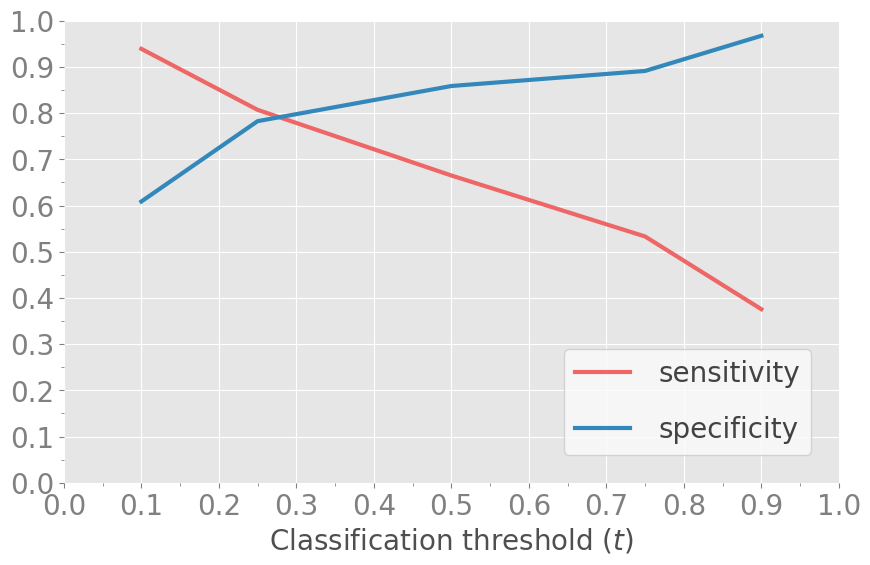

In [73]:
thresh_col = "Classification threshold ($\it{t}$)"

# LONDON HETEROGENEOUS AFTER MAY 15
# metrics_df = pd.DataFrame({
#     thresh_col: [0.1, 0.25, 0.5, 0.75, 0.9],
#     "sensitivity": [0.9278, 0.8454, 0.6907, 0.5412, 0.3608],
#     "specificity": [0.8008, 0.9173, 0.9549, 0.9925, 1.0]
# })

# # OTTAWA HETEROGENEOUS
metrics_df = pd.DataFrame({
    thresh_col: [0.1, 0.25, 0.5, 0.75, 0.9],
    "sensitivity": [0.9391, 0.8071, 0.6650, 0.5330, 0.3756],
    "specificity": [0.6087, 0.7826, 0.8587, 0.8913, 0.9674]
})

fig, ax = plt.subplots(1, figsize=(10,6))
ax.plot(metrics_df[thresh_col], metrics_df["sensitivity"])
ax.plot(metrics_df[thresh_col], metrics_df["specificity"])
ax.set_xlabel(thresh_col)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xticks(np.arange(0.0, 1.1, 0.1), minor=False)
ax.set_xticks(np.arange(0.0, 1.05, 0.05), minor=True)
ax.set_yticks(np.arange(0.0, 1.1, 0.1), minor=False)
ax.set_yticks(np.arange(0.0, 1.05, 0.05), minor=True)
ax.set_autoscale_on(False)
ax.legend(["sensitivity", "specificity"], loc='lower right')
plt.show()

# Sensitivity/Specificity Contiguity Threshold Analysis

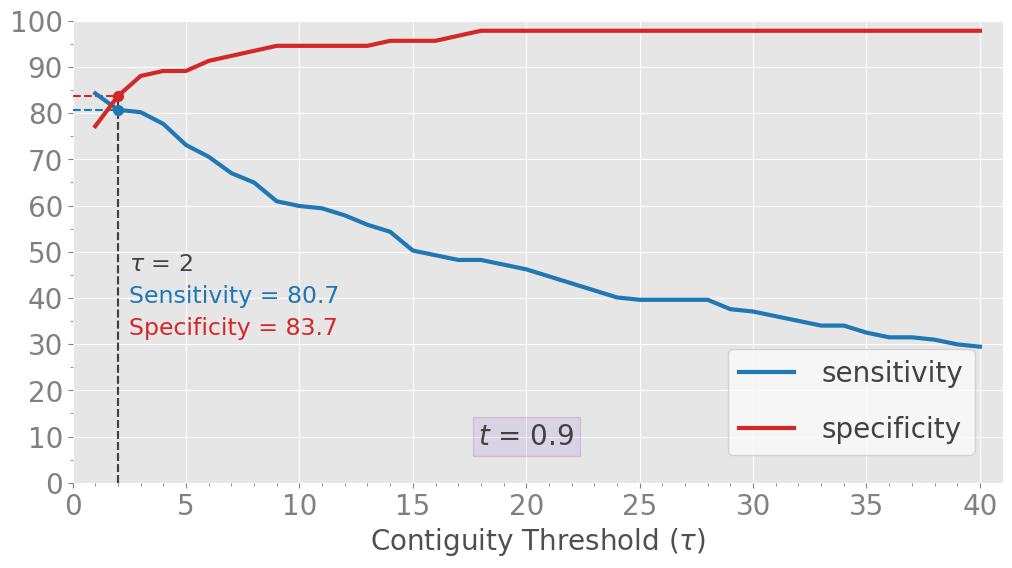

In [41]:
class_thresh = 0.9
EXP3_DATA_PATH = "C:\\Users\\Blake\\Downloads\\Thresholds\\Ottawa Full\\exp3_contiguous\\b-line_thresholds_{}c.csv".format(class_thresh)
#EXP3_DATA_PATH = "C:\\Users\\Blake\\Downloads\\Thresholds\\London May 15\\exp3_contiguous\\contiguous_{}c.csv".format(class_thresh)
metrics_df = pd.read_csv(EXP3_DATA_PATH)
metrics_df["sensitivity"] = metrics_df["recall"]
metrics_df["sensitivity"] = metrics_df["sensitivity"] * 100
metrics_df["specificity"] = metrics_df["specificity"] * 100
metrics_df = metrics_df.iloc[1: , :]
min_threshold = 1
max_threshold = 40
thresh_col = "B-line Threshold"
metrics_to_plot=["sensitivity", "specificity"]
x_label = "Contiguity Threshold"

fig, ax = plt.subplots(1, figsize=(12,6))
x_minor_locator = ticker.AutoMinorLocator(5)
y_minor_locator = ticker.AutoMinorLocator(2)
ax.xaxis.set_minor_locator(x_minor_locator)
ax.yaxis.set_minor_locator(y_minor_locator)
ax.set_ylim(0., 100.)
ax.set_xlim(min_threshold - 1, max_threshold + 1)
ax.set_xticks(np.arange(0, max_threshold + 1, 5), minor=False)
ax.set_xticks(np.arange(0, max_threshold + 1, 1), minor=True)
ax.set_yticks(np.arange(0., 101., 10.), minor=False)
ax.set_yticks(np.arange(0., 101., 5.), minor=True)
ax.set_xlabel(r"Contiguity Threshold ($\it{\tau}$)")

ax.plot(metrics_df[thresh_col], metrics_df["sensitivity"], color="tab:blue")
ax.plot(metrics_df[thresh_col], metrics_df["specificity"], color="tab:red")

ax.legend(["sensitivity", "specificity"], loc='lower right')

x_itn, sens_itn, spec_itn = get_intersection_point(np.arange(min_threshold, max_threshold + 1), 
                                                      metrics_df["sensitivity"].to_numpy(),
                                                      metrics_df["specificity"].to_numpy())
ax.vlines(x_itn, 0, sens_itn, linestyle="dashed", linewidth=1.5, color='#424242')
ax.vlines(x_itn, 0, spec_itn, linestyle="dashed", linewidth=1.5, color='#424242')
ax.hlines(sens_itn, 0, x_itn, linestyle="dashed", linewidth=1.5, color='tab:blue')
ax.plot(x_itn, sens_itn, 'ro', color='tab:blue', markersize=7)
ax.hlines(spec_itn, 0, x_itn, linestyle="dashed", linewidth=1.5, color='tab:red')
ax.plot(x_itn, spec_itn, 'ro', color='tab:red', markersize=7)
ax.text(x_itn + 0.5, sens_itn / 2 + 7, r"$\it{\tau}$" + " = {}".format(x_itn), 
        ha='left', va='center', fontsize=17, color='#424242')
ax.text(x_itn + 0.5, sens_itn / 2, "Sensitivity = {:.1f}".format(sens_itn), 
        ha='left', va='center', fontsize=17, color="tab:blue")
ax.text(x_itn + 0.5, sens_itn / 2 - 7, "Specificity = {:.1f}".format(spec_itn), 
        ha='left', va='center', fontsize=17, color="tab:red")

thresh_t = ax.text(20, 10, '$\it{t}$ = ' + str(class_thresh), transform=ax.transData, fontsize=20, color='#424242', ha='center', va='center')
thresh_t.set_bbox(dict(facecolor='mediumpurple', alpha=0.15, edgecolor='purple'))
plt.show()

In [11]:
cfg = yaml.full_load(open(os.getcwd() + "/config.yml", 'r'))
kfold_test_set_dir = "C:\\Users\\Blake\\Documents\\Work\\AlveolAI-DataFuel\\ab-line-classifer\\data\\partitions\\kfold_cutoffvgg16cropped\\"
kfold_models_dir = "C:\\Users\\Blake\\Documents\\Work\\AlveolAI-DataFuel\\ab-line-classifer\\results\\models\\kfold_cutoffvgg16cropped\\"
frames_dir = "B:\\Datasets\\data_actually_cropped"
k = 10
_, preprocessing_fn = get_model("cutoffvgg16")

a_tprs, a_fprs, b_tprs, b_fprs, fold_metrics = [], [], [], [], []

for i in tqdm.tqdm(range(k)):
    model = load_model(os.path.join(kfold_models_dir, "fold" + str(i) + ".h5"), compile=False)
    test_set = pd.read_csv(os.path.join(kfold_test_set_dir, "fold_" + str(i) + "_test_set.csv"))
    b_labels = np.array(test_set["Class"])
    pred_classes, pred_probs = predict_set(model, preprocessing_fn, test_set, frames_dir, threshold=0.5)
    metrics = compute_metrics(cfg, b_labels, np.array(pred_classes), pred_probs)
    
    a_labels = 1 - b_labels
    a_fpr, a_tpr, _ = roc_curve(a_labels, pred_probs[:, 0])
    b_fpr, b_tpr, _ = roc_curve(b_labels, pred_probs[:, 1])
    a_tprs.append(a_tpr)
    b_tprs.append(b_tpr)
    a_fprs.append(a_fpr)
    b_fprs.append(b_fpr)
    fold_metrics.append(metrics)
    del model

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Found 22728 validated image filenames belonging to 2 classes.


 10%|████████▎                                                                          | 1/10 [01:31<13:40, 91.14s/it]

Found 27273 validated image filenames belonging to 2 classes.


C:\Users\Blake\anaconda3\lib\site-packages\tensorflow\python\keras\engine\training.py:2001: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  warnings.warn('`Model.predict_generator` is deprecated and '
 20%|████████████████▍                                                                 | 2/10 [03:31<13:20, 100.00s/it]

...

C:\Users\Blake\anaconda3\lib\site-packages\tensorflow\python\keras\engine\training.py:2001: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  warnings.warn('`Model.predict_generator` is deprecated and '
 80%|██████████████████████████████████████████████████████████████████▍                | 8/10 [12:38<02:35, 77.78s/it]

Found 22860 validated image filenames belonging to 2 classes.


C:\Users\Blake\anaconda3\lib\site-packages\tensorflow\python\keras\engine\training.py:2001: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  warnings.warn('`Model.predict_generator` is deprecated and '
 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [13:13<01:04, 64.91s/it]

Found 27060 validated image filenames belonging to 2 classes.


C:\Users\Blake\anaconda3\lib\site-packages\tensorflow\python\keras\engine\training.py:2001: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  warnings.warn('`Model.predict_generator` is deprecated and '
100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [13:54<00:00, 83.48s/it]


In [6]:
with open("results/experiments/fold_metrics.json", 'r') as f:
    fold_metrics = json.load(f)

In [7]:
metric_names = list(fold_metrics[0].keys())
metric_means, metric_stdevs = {}, {}
for metric in metric_names:
    metric_means[metric] = np.mean(np.array([fold_metrics[i][metric] for i in range(len(fold_metrics))]))
    metric_stdevs[metric] = np.std(np.array([fold_metrics[i][metric] for i in range(len(fold_metrics))]))
print("Metric means: ", metric_means, "\n")
print("Metric standard deviations: ", metric_stdevs)

Metric means:  {'confusion_matrix': 6822.275, 'precision': 0.8913402960283966, 'recall': 0.8576415988284353, 'specificity': 0.9471166225507529, 'f1': 0.8736759490671439, 'accuracy': 0.9210227907617128, 'macro_mean_auc': 0.9644415632382038, 'weighted_mean_auc': 0.9644415632382038, 'a_lines_auc': 0.9644440424447325, 'b_lines_auc': 0.9644415632382038} 

Metric standard deviations:  {'confusion_matrix': 7139.046606471693, 'precision': 0.04674927153226532, 'recall': 0.0499895671717382, 'specificity': 0.03583371043379152, 'f1': 0.0444196423584701, 'accuracy': 0.03432427420765173, 'macro_mean_auc': 0.019146445185592702, 'weighted_mean_auc': 0.019146445185592702, 'a_lines_auc': 0.019142217732972956, 'b_lines_auc': 0.019146445185592702}


# ROC Curves

## Internal -  homeogeneous clips (k-fold average)

In [8]:
base_fpr = np.linspace(0, 1, 1001)
a_tpr_itpls = []
for i in range(k):
    a_tpr_itpls.append(np.interp(base_fpr, a_fprs[i], a_tprs[i]))
a_tpr_itpls = np.array(a_tpr_itpls)

b_tpr_itpls = []
for i in range(k):
    b_tpr_itpls.append(np.interp(base_fpr, b_fprs[i], b_tprs[i]))
b_tpr_itpls = np.array(b_tpr_itpls)

IndexError: list index out of range

In [13]:
a_mean_tprs = a_tpr_itpls.mean(axis=0)
a_std = a_tpr_itpls.std(axis=0)
a_tprs_upper = np.minimum(a_mean_tprs + a_std, 1)
a_tprs_lower = a_mean_tprs - a_std

b_mean_tprs = b_tpr_itpls.mean(axis=0)
b_std = b_tpr_itpls.std(axis=0)
b_tprs_upper = np.minimum(b_mean_tprs + b_std, 1)
b_tprs_lower = b_mean_tprs - b_std

avg_a_auc = np.mean(np.array([fold_metrics[i]['a_lines_auc'] for i in range(k)]))
avg_b_auc = np.mean(np.array([fold_metrics[i]['b_lines_auc'] for i in range(k)]))
std_a_auc = np.std(np.array([fold_metrics[i]['a_lines_auc'] for i in range(k)]))
std_b_auc = np.std(np.array([fold_metrics[i]['b_lines_auc'] for i in range(k)]))

AttributeError: 'list' object has no attribute 'mean'

In [12]:
# PLOT ROC
plt.clf()
amaranth = "#E52B50"
bright_navy_blue = "#1974D2"
fig, ax = plt.subplots(1, figsize=(8,6))
#ax.plot(base_fpr, a_mean_tprs, amaranth)
ax.plot(base_fpr, b_mean_tprs, bright_navy_blue)
#ax.fill_between(base_fpr, a_tprs_lower, a_tprs_upper, color=amaranth, alpha=0.3)
ax.fill_between(base_fpr, b_tprs_lower, b_tprs_upper, color=bright_navy_blue, alpha=0.2)

ax.plot([0, 1], [0, 1], color='gray', linestyle='dashed', linewidth=2)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xticks(np.arange(0.0, 1.1, 0.1), minor=False)
ax.set_xticks(np.arange(0.0, 1.05, 0.05), minor=True)
ax.set_yticks(np.arange(0.0, 1.1, 0.1), minor=False)
ax.set_yticks(np.arange(0.0, 1.05, 0.05), minor=True)
ax.set_ylabel('True Positive Rate')
ax.set_xlabel('False Positive Rate')
ax.set_autoscale_on(False)
ax.legend(["ROC (AUC = {:.3f} \u00B1 {:.3f})".format(avg_b_auc, std_b_auc), "Naive classifier"], loc='lower right', fontsize=16)
plt.show()

NameError: name 'b_mean_tprs' is not defined

## External - homogeneous clips

In [19]:
cfg = yaml.full_load(open(os.getcwd() + "/config.yml", 'r'))
dataset_root = "B:\\Datasets\\pure_external\\pure"
ext_test_set_path = os.path.join(dataset_root, "frames_ext.csv")
frames_dir = os.path.join(dataset_root, "frames_ext")
model_path = "C:\\Users\\Blake\\Documents\\Work\\AlveolAI-DataFuel\\ab-line-classifer\\results\\models\\cutoffvgg16_final_cropped.h5"
k = 10
_, preprocessing_fn = get_model("cutoffvgg16")


model = load_model(model_path, compile=False)
ext_test_set = pd.read_csv(ext_test_set_path)
b_labels = np.array(ext_test_set["Class"])
pred_classes, pred_probs = predict_set(model, preprocessing_fn, ext_test_set, frames_dir, threshold=0.5)
ext_homo_metrics = compute_metrics(cfg, b_labels, np.array(pred_classes), pred_probs)

a_labels = 1 - b_labels
a_fpr, a_tpr, _ = roc_curve(a_labels, pred_probs[:, 0])
b_fpr, b_tpr, _ = roc_curve(b_labels, pred_probs[:, 1])

Found 23393 validated image filenames belonging to 2 classes.


C:\Users\Blake\anaconda3\lib\site-packages\tensorflow\python\keras\engine\training.py:2001: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  warnings.warn('`Model.predict_generator` is deprecated and '


In [26]:
print("External homogeneous frame metrics: ", ext_homo_metrics)

External homogeneous frame metrics:  {'confusion_matrix': [[9492, 1314], [2369, 10218]], 'precision': 0.8860561914672217, 'recall': 0.8117899420036546, 'specificity': 0.8784008883953359, 'f1': 0.8472988100667525, 'accuracy': 0.8425597400931902, 'macro_mean_auc': 0.92563169556985, 'weighted_mean_auc': 0.92563169556985, 'a_lines_auc': 0.9256236670507857, 'b_lines_auc': 0.92563169556985}


<Figure size 640x480 with 0 Axes>

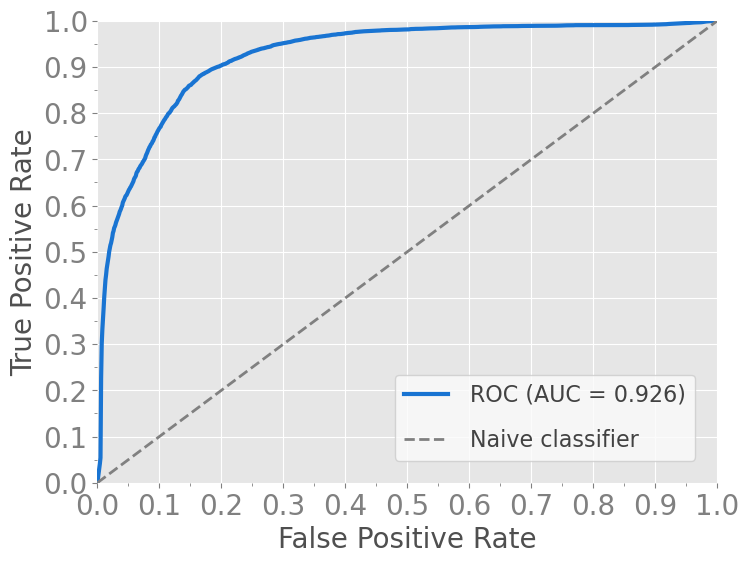

In [27]:
plt.clf()
amaranth = "#E52B50"
bright_navy_blue = "#1974D2"
fig, ax = plt.subplots(1, figsize=(8,6))
base_fpr = np.linspace(0, 1, 1001)
b_tpr_itpls = np.interp(base_fpr, b_fpr, b_tpr)
ax.plot(base_fpr, b_tpr_itpls, bright_navy_blue)

ax.plot([0, 1], [0, 1], color='gray', linestyle='dashed', linewidth=2)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xticks(np.arange(0.0, 1.1, 0.1), minor=False)
ax.set_xticks(np.arange(0.0, 1.05, 0.05), minor=True)
ax.set_yticks(np.arange(0.0, 1.1, 0.1), minor=False)
ax.set_yticks(np.arange(0.0, 1.05, 0.05), minor=True)
ax.set_ylabel('True Positive Rate')
ax.set_xlabel('False Positive Rate')
ax.set_autoscale_on(False)
ax.legend(["ROC (AUC = {:.3f})".format(ext_homo_metrics['b_lines_auc']), "Naive classifier"], loc='lower right', fontsize=16)
plt.show()

# Confusion Matrices

## Internal -  homeogeneous frames (k-fold average)

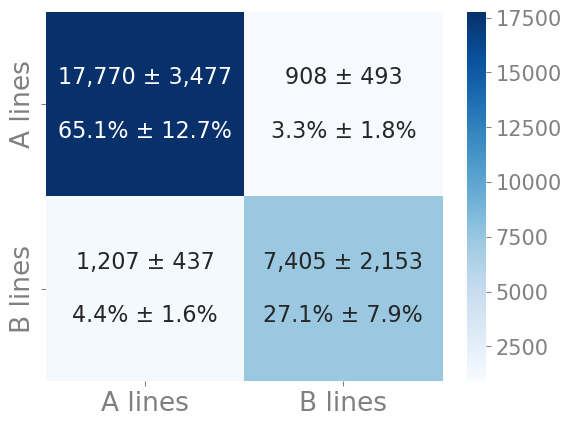

In [17]:
# PLOT CONFUSION MATRIX
cfs = np.vstack([np.array([fold_metrics[i]['confusion_matrix'] for i in range(len(fold_metrics))])])
cf_mean = np.mean(cfs, axis=0)
cf_std = np.std(cfs, axis=0)

group_means = ["{:,.0f}".format(f) for f in cf_mean.flatten()]
group_stds = ["{:,.0f}".format(s) for s in cf_std.flatten()]
group_mean_percent = ["{0:.1%}".format(f) for f in cf_mean.flatten() / np.sum(cf_mean)]
group_std_percent = ["{0:.1%}".format(s) for s in cf_std.flatten() / np.sum(cf_mean)]
labels = [f"{m} \u00B1 {s}\n\n{mp} \u00B1 {sp}" for m, s, mp, sp in zip(group_means, group_stds, group_mean_percent, group_std_percent)]
labels = np.asarray(labels).reshape(2,2)
categories = ["A lines", "B lines"]

cm = sns.heatmap(cf_mean, annot=labels, fmt="", cmap="Blues", xticklabels=categories, yticklabels=categories, 
                 annot_kws={"size": 16})
cm.set_xticklabels(cm.get_xmajorticklabels(), fontsize = 19)
cm.set_yticklabels(cm.get_ymajorticklabels(), fontsize = 19, va='center')
cbar = cm.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
plt.show()

## External -  homeogeneous frames (k-fold average)

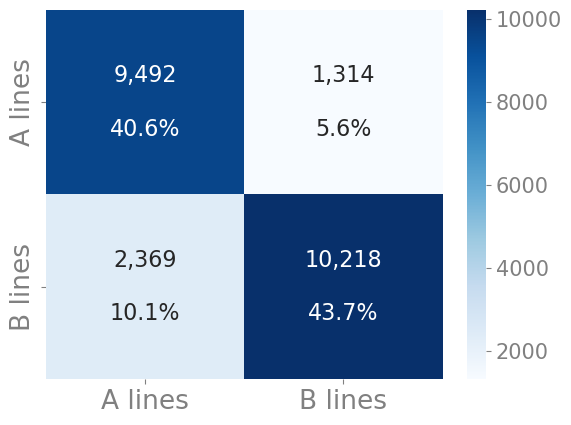

In [22]:
# PLOT CONFUSION MATRIX
cf = np.array(ext_homo_metrics['confusion_matrix'])

vals = ["{:,.0f}".format(f) for f in cf.flatten()]
percents = ["{0:.1%}".format(f) for f in cf.flatten() / np.sum(cf)]
labels = [f"{m}\n\n{p}" for m, p, in zip(vals, percents)]
labels = np.asarray(labels).reshape(2,2)
categories = ["A lines", "B lines"]

cm = sns.heatmap(cf, annot=labels, fmt="", cmap="Blues", xticklabels=categories, yticklabels=categories, annot_kws={"size": 16})
cm.set_xticklabels(cm.get_xmajorticklabels(), fontsize = 19)
cm.set_yticklabels(cm.get_ymajorticklabels(), fontsize = 19, va='center')
cbar = cm.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
plt.show()